 
--- header info ---
Tue  6 Oct 15:40:11 BST 2026
BDNAME  N1470
BDSNUM  236
BDFREL  2.03
BDCTR   REMOTE
BDILK   NO
CH     VSET     VMON     ISET     IMON      RUP      RDW     MAXV      POL     STAT  flags
 0   2100.0   2099.8  1600.00  0320.35      050      050     2300        -    00001  ON
 1   2200.0   0000.2  1600.00  0000.00      050      050     2300        -    02048  KILL
 2   2100.0   0000.0  1600.00  0000.00      050      050     2500        -    02048  KILL
 3   1250.0   0000.4  1600.00  0000.00      050      050     2500        -    02048  KILL
units: V, uA, V/s

THOR_X:read_pos                65
THOR_Y:read_pos                82

 
--- Event loop ---
2 [2121. 2121. 2122. ... 2121. 2122. 2123.]
3 [2102. 2102. 2100. ... 2102. 2101. 2105.]


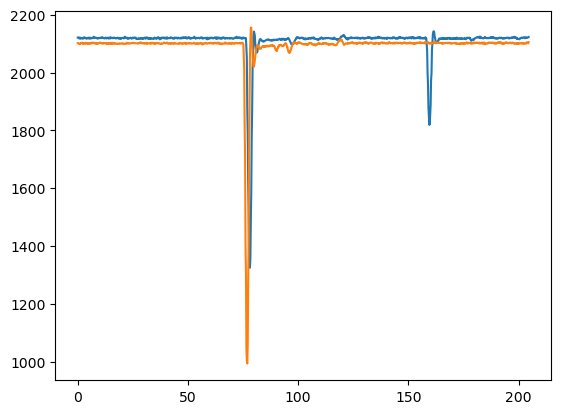

In [ ]:
import hpdirc                           # for reading HPDIRC data files
import matplotlib.pyplot as plt         # for plotting

run = hpdirc.Run("data/test-00000068-0000.evt", calib="data/calib_0049_5G.dat")

# access other packet information
print(run.hv())        # HV settings/readback at the start of the run
print(run.motor())     # motor x/y position

for ev in run.events(max_events=2):
    # with these 5 attributes you can access the waveform and trigger information for each event:
    ev.wave       # (32, 1024) waveform for each channel in ADC counts, calibrated
    ev.time       # (32, 1024) time samples for each channel in ns
    ev.trig       # (4, 1024)  trigger signal of each group of 8 channels
    ev.trigtime   # (4, 1024) time samples of the trigger signal in ns
    ev.number     # event number 

    # e.g. plot the 20th channel of the first 10 events
    print(ev.number, ev.wave[20])  # event number and 20th channel
    plt.plot(ev.time[20], ev.wave[20])  # plot 20th channel